In [2]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm, trange
from datasets import load_dataset

c:\Users\Shaz\AppData\Local\pypoetry\Cache\virtualenvs\interp-toxicity-8bazFRdd-py3.9\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## JigSaw

In [2]:
ablation_scores = torch.load("ablation_scores.pth")

/tmp/ipykernel_1338923/1892869343.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ablation_scores = torch.load("ablation_scores.pth")


In [3]:
ablation_scores.shape

torch.Size([12, 12])

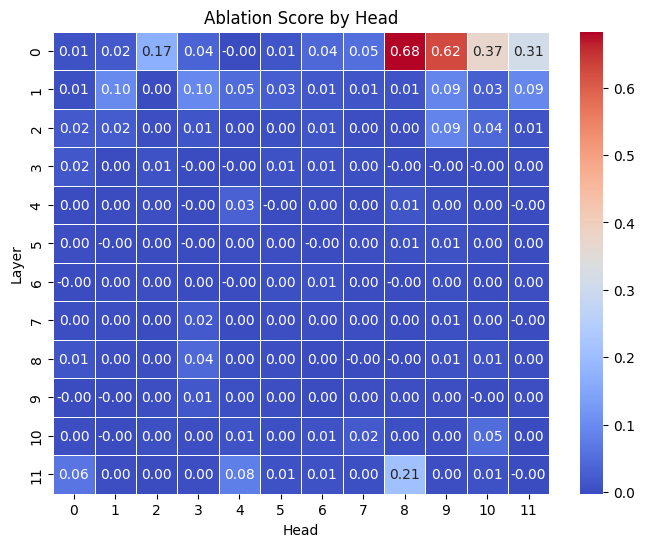

In [4]:
tensor_np = ablation_scores.cpu().detach().numpy() 

# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.savefig('ablation_scores_by_head.png')
# Show the plot
plt.show()

In [7]:
base_preds = json.load(open('base_preds.json'))

In [9]:
ablated_preds = json.load(open('ablated_preds.json'))

In [12]:
df = pd.read_csv('jigsaw/test.csv')

In [28]:
base_acc = (df.toxic == base_preds).mean()

In [31]:
acc_scores = np.zeros((12,12))
for i in trange(12):
    for j in range(12):
        acc_scores[i][j] = (df.toxic == ablated_preds[str(i)][str(j)]).mean()

  0%|          | 0/12 [00:00<?, ?it/s]

In [29]:
acc_scores -= base_acc

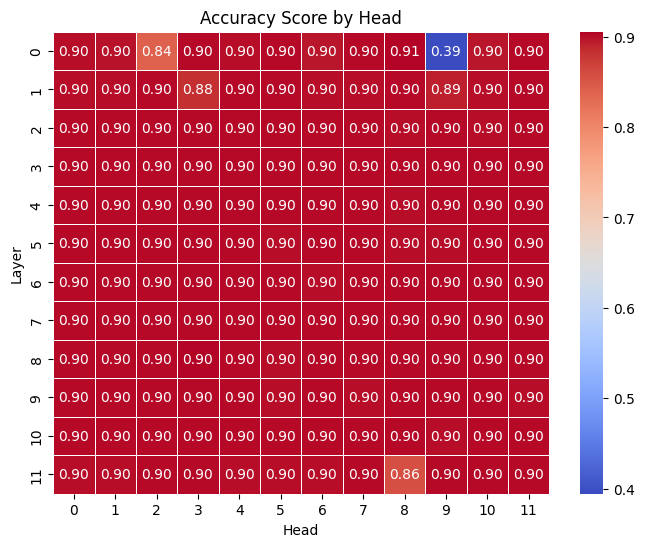

In [33]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(acc_scores, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.savefig('accuracy_scores_by_head.png')
# Show the plot
plt.show()

## Toxigen

In [2]:
data = load_dataset('toxigen/toxigen-data', 'train')

In [14]:
df = pd.DataFrame(data['train'])

In [16]:
topk_df = df[df.generation_method == 'top-k'].reset_index(drop=True)
alice_df = df[df.generation_method == 'ALICE'].reset_index(drop=True)

In [20]:
abs(topk_df.prompt_label - topk_df.roberta_prediction).mean()

0.5016049215814747

In [27]:
(topk_df.roberta_prediction.round() == topk_df.prompt_label).mean()

0.4983661079364026

In [28]:
(alice_df.roberta_prediction.round() == alice_df.prompt_label).mean()

0.5361402793353043

In [31]:
load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['prompt', 'generation', 'generation_method', 'group', 'prompt_label', 'roberta_prediction'],
        num_rows: 9809
    })
})

In [35]:
alice_df.generation.apply(lambda x: len(x.split())).max()

30

In [36]:
ablation_scores = torch.load("ablation_scores_alice.pth")

/tmp/ipykernel_3966/2482639629.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ablation_scores = torch.load("ablation_scores_alice.pth")


In [37]:
ablation_scores.shape

torch.Size([12, 12])

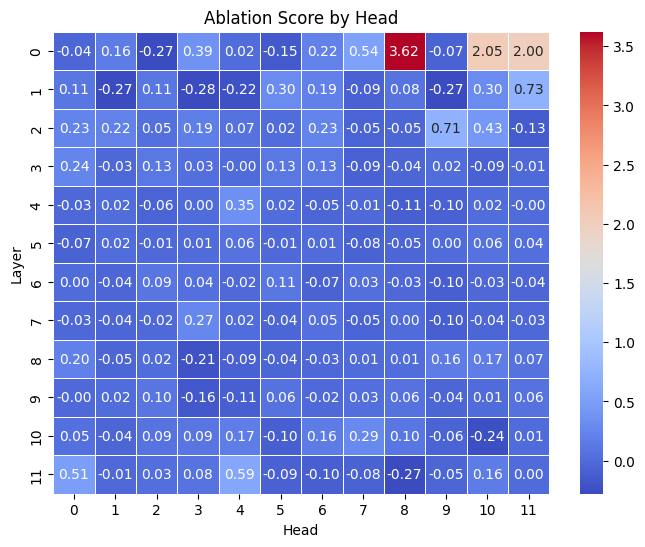

In [38]:
tensor_np = ablation_scores.cpu().detach().numpy() 

# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.savefig('ablation_scores_by_head.png')
# Show the plot
plt.show()

In [39]:
base_preds = json.load(open('base_preds_alice.json'))

In [40]:
ablated_preds = json.load(open('ablated_preds_alice.json'))

In [41]:
df = pd.read_csv('toxigen_alice.csv')

In [42]:
base_acc = (df.prompt_label == base_preds).mean()

In [43]:
base_acc

0.5769191558772556

In [44]:
acc_scores = np.zeros((12,12))
for i in trange(12):
    for j in range(12):
        acc_scores[i][j] = (df.prompt_label == ablated_preds[str(i)][str(j)]).mean()

  0%|          | 0/12 [00:00<?, ?it/s]

In [45]:
acc_scores -= base_acc

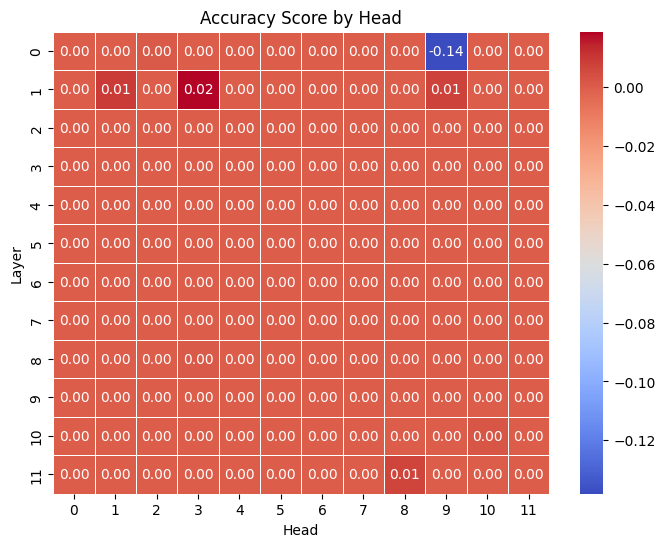

In [46]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(acc_scores, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.savefig('accuracy_scores_by_head.png')
# Show the plot
plt.show()

## BERT Jigsaw

In [5]:
ablation_scores = torch.load("bert_ablation_scores_jigsaw.pth")

/tmp/ipykernel_41007/513956281.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ablation_scores = torch.load("bert_ablation_scores_jigsaw.pth")


In [6]:
ablation_scores.shape

torch.Size([12, 12])

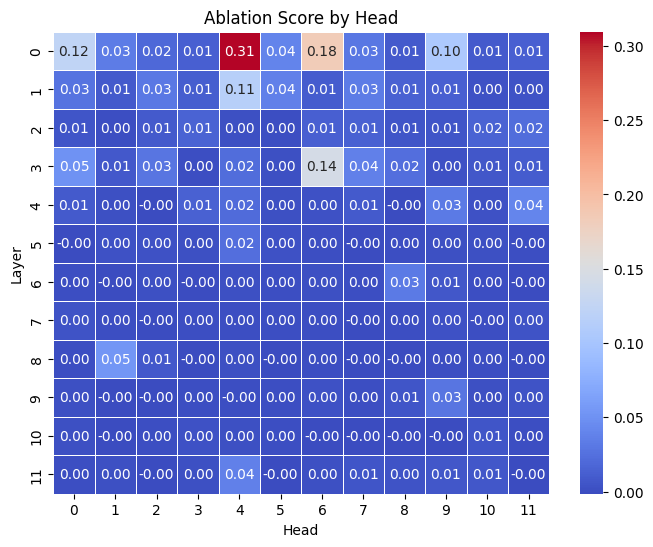

In [7]:
tensor_np = ablation_scores.cpu().detach().numpy() 

# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.savefig('ablation_scores_by_head.png')
# Show the plot
plt.show()

In [8]:
base_preds = json.load(open('bert_base_preds_jigsaw.json'))

In [9]:
ablated_preds = json.load(open('bert_ablated_preds_jigsaw.json'))

In [10]:
df = pd.read_csv('jigsaw/test.csv')

In [11]:
base_acc = (df.toxic == base_preds).mean()

In [12]:
acc_scores = np.zeros((12,12))
for i in trange(12):
    for j in range(12):
        acc_scores[i][j] = (df.toxic == ablated_preds[str(i)][str(j)]).mean()

  0%|          | 0/12 [00:00<?, ?it/s]

In [13]:
acc_scores -= base_acc

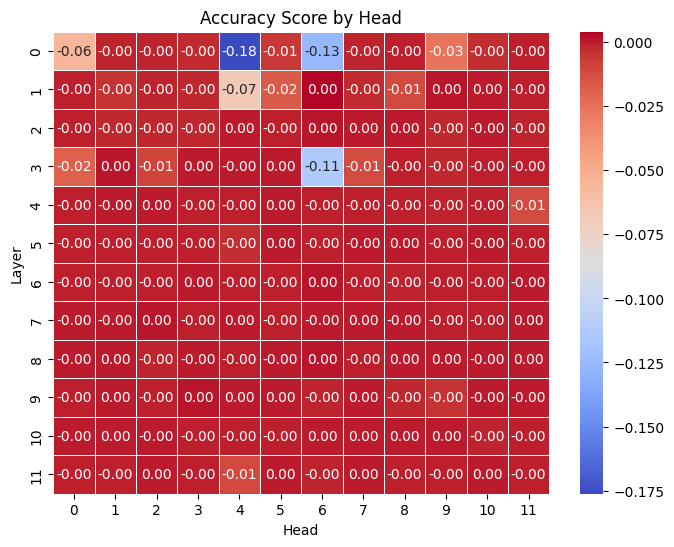

In [14]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(acc_scores, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.savefig('accuracy_scores_by_head.png')
# Show the plot
plt.show()